In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.montecarlo import get_OLS_estimates, get_IV_estimates
from src.metrics import get_metrics
from src.plots import plot_heatmap, plot_histogram, plot_metrics

# Ordinary Least Squares

---



Consider the equation $\vec Y=\beta \mathbb{X} + \vec\epsilon$. When $\mathbb{X}$ and $\vec\epsilon$ are uncorrelated, ordinary least squares through the origin gives the unbiased estimator $$\hat{\vec{\beta}}^{OLS}=\left(\mathbb{X}^T\mathbb{X}\right)^{-1}\mathbb{X}^T\vec Y.$$
When $\mathbb{X}$ is a column vector, this simplifies to $$\hat\beta^{OLS}=\frac{\vec X\cdot \vec Y}{\vec X\cdot\vec X}.$$

Now consider when $\mathbb{X}$ and $\vec \epsilon$ are correlated. For example, let
$$
X=\pi Z+\gamma U+\epsilon_X,
$$
$$
Y=\beta X + U + \epsilon_Y,
$$
where $Z$, $U$, $\epsilon_X$, and $\epsilon_Y$ are independently generated from $N(0,1)$. Applying the formula from before, we have

$$
\hat\beta^{OLS}=\frac{\beta\vec{X}\cdot\vec{X}+\vec{X}\cdot \vec{U} + \vec{X}\cdot \vec{\epsilon_Y}}{\vec{X}\cdot\vec{X}}=\beta+\frac{\vec{X}\cdot(\vec{U}+\vec{\epsilon_Y})}{\vec{X}\cdot\vec{X}}.
$$ 

We can expand the numerator and denominator and apply the law of large numbers to get $$\frac 1n \vec X\cdot(\vec U+\vec\epsilon_Y)\overset{P}\rightarrow \gamma E(U^2)=\gamma,$$ $$\frac 1n \vec X\cdot\vec X\overset{P}\rightarrow \pi^2E(Z^2)+\gamma^2E(U^2)+E(\epsilon_X^2)=\pi^2+\gamma^2+1,$$ because $E(ZU)=E(Z)E(U)=0$ and analogous relations.

Then, by the continuous mapping theorem, $$\hat\beta^{OLS}\overset{P}\rightarrow\beta+\frac{\gamma}{\pi^2+\gamma^2+1}$$ and $\hat\beta^{OLS}$ is not a consistent estimator.

Empirically, we see that $\hat\beta^{OLS}$ is biased.

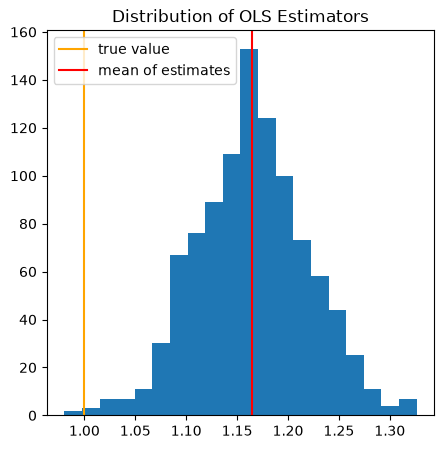

In [2]:
N = 1000
data_kwargs = dict(
    data_size = 100,
    pi = 2.0,
    gamma = 1.0,
    beta = 1.0
)

beta_OLS_estimates = get_OLS_estimates(N, **data_kwargs)
plot_histogram([beta_OLS_estimates], ["Distribution of OLS Estimators"], data_kwargs["beta"])

# Instrumental Variables


---



When we introduce $Z$ as an instrumental variable, we first use OLS to regress $X$ onto $Z$, then to regress $Y$ onto $\hat X$. From the first step, we get $$\hat\pi^{OLS}=\frac{\vec Z\cdot \vec X}{\vec Z\cdot\vec Z}$$ and so $$\hat X=\frac{\vec Z\cdot \vec X}{\vec Z\cdot\vec Z}\vec Z.$$ Then, when we regress $Y$ onto $\hat X$, we get
$$\hat\beta^{IV}=\frac{\beta\frac{\left(\vec Z\cdot \vec X\right)^2}{\vec Z\cdot\vec Z} + \frac{\vec Z\cdot \vec X}{\vec Z\cdot\vec Z}\vec Z\cdot(\vec U+\vec\epsilon_Y)}{\frac{\left(\vec Z\cdot \vec X\right)^2}{\vec Z\cdot\vec Z}}=\beta+\frac{\vec Z\cdot(\vec U+\vec \epsilon_Y)}{\vec Z\cdot \vec X}.$$
We know that $\vec Z$, $\vec U$, and $\vec\epsilon_Y$ are independent and $\vec Z$ and $\vec X$ are correlated. By the law of large numbers, letting $n$ be the sample size, we have that $$\lim_{n\rightarrow \infty}\frac 1n \vec Z \cdot(\vec U + \vec\epsilon_Y)=E\left[Z\left(U+\epsilon_Y\right)\right]=0,$$
$$\lim_{n\rightarrow \infty}\frac 1n \vec Z \cdot\vec X=E\left[Z X\right]\ne 0.$$ By the continuous mapping theorem, we have that $$\frac{\frac 1n \vec Z \cdot(\vec U + \vec\epsilon_Y)}{\frac 1n \vec Z \cdot\vec X}\overset{P}\rightarrow0.$$ Therefore, $\hat\beta^{IV}\xrightarrow{P}\beta$, so $\hat\beta^{IV}$ is consistent.

Empirically, we see that $\hat\beta^{IV}$ exhibits less bias than $\hat\beta^{OLS}$ does.

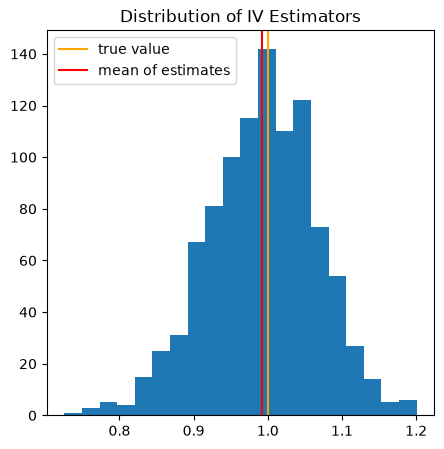

In [3]:
beta_IV_estimates = get_IV_estimates(N, **data_kwargs)
plot_histogram([beta_IV_estimates], ["Distribution of IV Estimators"], data_kwargs["beta"])

# First Stage Assumption


---

The instrumental variable ($Z$ in our setup) must have a causal effect on the treatment variable ($X$ in our setup).

We can see that when we decrease the first stage coefficient, instrumental variables becomes less useful. Although $E\left[\hat\beta^{IV}\right]$ is still $\beta$, we can see that $\hat\beta^{OLS}$ becomes unstable and its variance increases.

We know from the previous section that $\text{var}\left(\hat\beta^{IV}\right)=\text{var}\left(\frac{\vec Z \cdot (\vec U + \vec\epsilon_Y)}{\vec Z\cdot\vec X}\right)$, which we can approximate with the delta method using $g(u,v)=\frac uv$. We have that $\nabla g = \left\langle \frac 1v, -\frac{u}{v^2}\right\rangle$. Plugging in $u=E\left[\vec Z\cdot(\vec U+\vec\epsilon_Y)\right]=0$ and $v=E\left[\vec Z\cdot\vec X\right]$, we have that
$$
\text{var}\left(\frac{\vec Z\cdot(\vec U+\vec\epsilon_Y)}{\vec Z\cdot\vec X}\right)\approx\frac{\text{var}\left(\vec Z\cdot(\vec U+\vec\epsilon_Y)\right)}{E\left[\vec Z\cdot\vec X\right]^2}.
$$ 
Our setup has $E\left[\vec Z\cdot\vec X\right]\propto\pi$, so $\text{var}\left(\hat\beta^{IV}\right)$ increases quadratically with respect to decreasing instrument strength.

(Pay attention to the x axis scale)

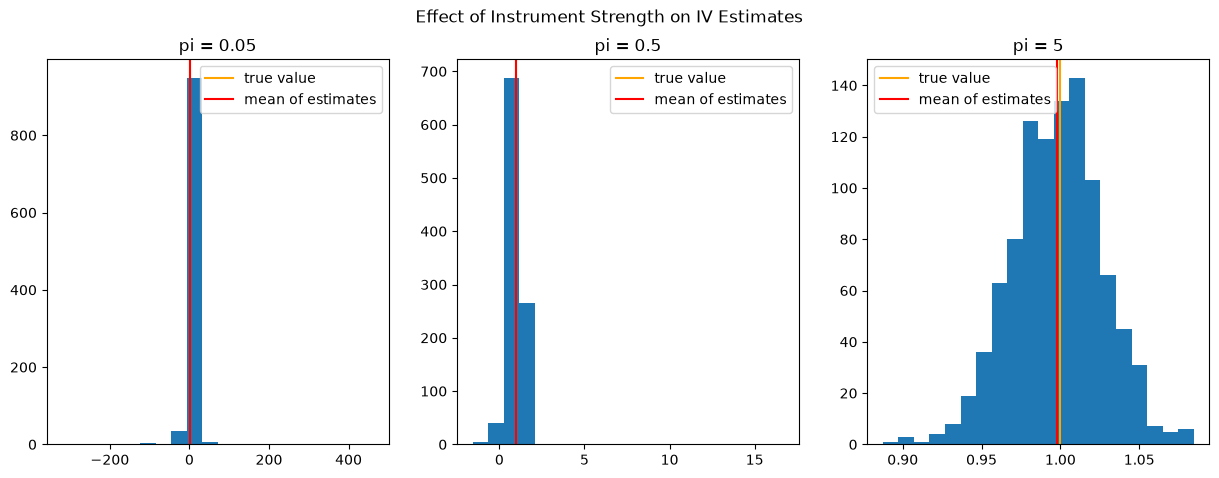

In [4]:
IV_estimates_list = []
pi_vals = [0.05, 0.5, 5]
for pi in pi_vals:
    data_kwargs["pi"] = pi
    beta_IV_estimates = get_IV_estimates(N, **data_kwargs)
    IV_estimates_list.append(beta_IV_estimates)
plot_histogram(IV_estimates_list, [f"pi = {p}" for p in pi_vals], data_kwargs["beta"], "Effect of Instrument Strength on IV Estimates")

# Exclusion Restriction Assumption


---


The instrumental variable must affect the dependent variable only through the explanatory variable.

To see what happens when we don't have exclusion restriction, we can let $X=\pi Z+\gamma U+\epsilon_X$ like before, and let $Y=\beta X+\delta Z+U+\epsilon_Y$. Like before, we still have $\hat X=\frac{\vec Z\cdot \vec X}{\vec Z\cdot\vec Z}\vec Z$. Then, the instrumental variables approach gives us
$$\hat\beta^{IV}=\frac{\beta\frac{(\vec Z\cdot\vec X)^2}{\vec Z\cdot\vec Z}+\delta\vec Z\cdot\vec X+\frac{\vec Z\cdot\vec X}{\vec Z\cdot\vec Z}\vec Z\cdot(\vec U+\vec\epsilon_Y)}{\frac{(\vec Z\cdot\vec X)^2}{\vec Z\cdot\vec Z}}=\beta+\delta\frac{\vec Z\cdot\vec Z}{\vec Z\cdot\vec X}+\frac{\vec Z\cdot(\vec U+\vec\epsilon_Y)}{\vec Z\cdot\vec X}.$$

By the law of large numbers, $\frac 1n\vec Z\cdot\vec Z\overset{P}\rightarrow E[Z^2]=1$ and $\frac 1n\vec Z\cdot\vec X\overset{P}\rightarrow E[ZX]=\pi$ (we assumed $Z$ and $X$ are both drawn from $N(0,1)$, so can get exact numbers).

We already found that $\frac{\vec Z\cdot(\vec U+\vec\epsilon_Y)}{\vec Z\cdot\vec X}\overset{P}\rightarrow0$, so as the sample size increases, $\hat\beta^{IV}$ overestimates $\beta$ by approximately $\frac{\delta}{\pi}$. When $\delta$ is small, exclusion restriction approximately holds, and so $\hat\beta^{IV}$ is approximately consistent.

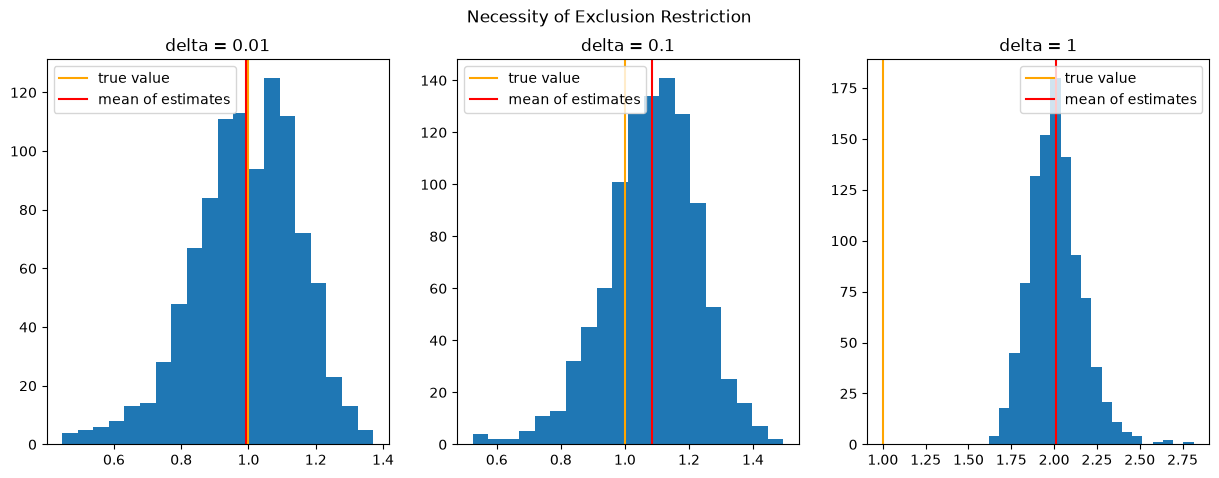

In [5]:
IV_estimates_list = []
data_kwargs["pi"] = 1
delta_vals = [0.01, 0.1, 1]
for delta in delta_vals:
    data_kwargs["delta"] = delta
    beta_IV_estimates = get_IV_estimates(N, **data_kwargs)
    IV_estimates_list.append(beta_IV_estimates)
plot_histogram(IV_estimates_list, [f"delta = {d}" for d in delta_vals], data_kwargs["beta"], "Necessity of Exclusion Restriction")

# When does Instrumental Variables Outperform Ordinary Least Squares?


---
Let's look at sample size first.

We can see that the bias for ordinary least squares is constant with respect to sample size, while the bias for instrumental variables tends towards $0$ as sample size increases. At very small sample sizes, instrumental variables can be more biased than ordinary least squares.

Variance decreases with sample size for both ordinary least squares and instrumental variables, though ordinary least squares consistently has lower variance than instrumental variables does with the same sample size.

Mean squared error satisfies $mse = var + bias^2$. At small sample sizes, ordinary least squares performs better than instrumental variables because of its lower variance. At large enough sample sizes, bias dominates variance for ordinary least squares, and so instrumental variables performs better.

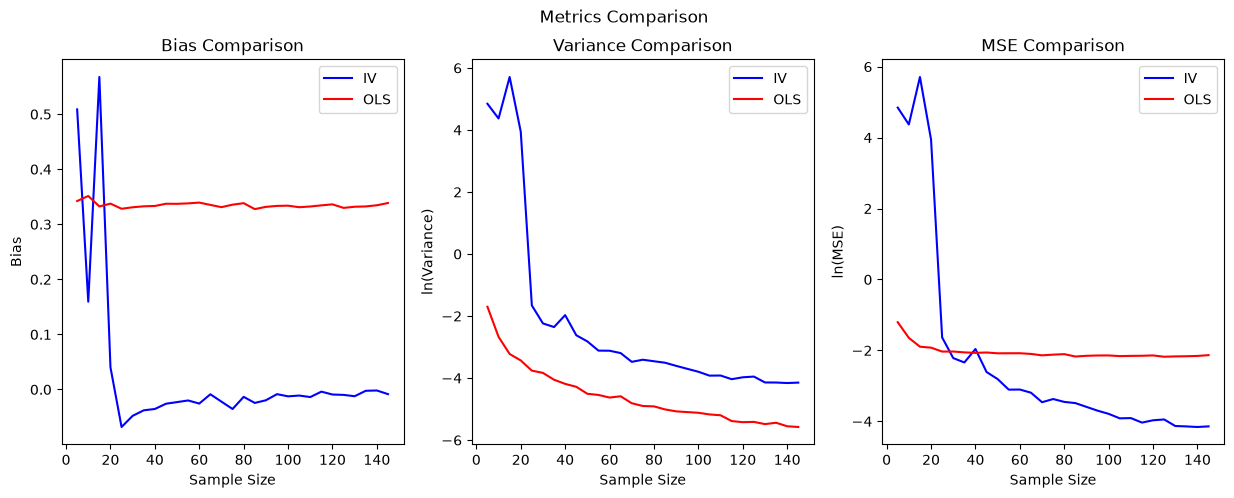

In [6]:
data_kwargs = dict(
    gamma = 1.0,
    beta = 1.0,
    pi = 1.0,
)

start = 5
stop = 150
step = 5
num = int((stop-start)/step)
data_sizes = range(start, stop, step)

OLS_trends = {
  "bias": [None]*num,
  "var": [None]*num,
  "mse": [None]*num
}

IV_trends = {
  "bias": [None]*num,
  "var": [None]*num,
  "mse": [None]*num
}

for i, data_size in enumerate(data_sizes):
  data_kwargs["data_size"] = data_size

  beta_IV_estimates = get_IV_estimates(N, **data_kwargs)
  beta_OLS_estimates = get_OLS_estimates(N, **data_kwargs)
  
  IV_metrics = get_metrics(beta_IV_estimates, data_kwargs["beta"])
  OLS_metrics = get_metrics(beta_OLS_estimates, data_kwargs["beta"])

  for metric in IV_metrics.keys():
    IV_trends[metric][i] = IV_metrics[metric]
    OLS_trends[metric][i] = OLS_metrics[metric]

plot_metrics(data_sizes, OLS_trends, IV_trends)

### When does instrumental variables outperform ordinary least squares?


---

Now let's look at instrument strength ($\pi$) and endogeneity strength ($\gamma$).

Smaller values of $\pi$ leads to larger variances for IV. The difference in variances between IV and OLS becomes less significant as $\pi$ increases.  

Very small and very large values of $\gamma$ leads to small biases for OLS. Intuitively, this is because we keep the effect of $U$ on $\gamma$ constant, and $\gamma$ controls the effect of $U$ on $X$. When $\gamma$ is very small, $U$ has negligible effect on $X$ and when $\gamma$ is very large $U$ has negligible effect on $Y$. In the following analysis, we assume $\gamma$ is not large enough for $U$ to have neglibgible effect on $Y$.

Then, if we use mean square errors as our metric, we have roughly four regions:

1. $\pi$ is small and $\gamma$ is small. OLS performs better because it has negligible bias, while IV has large variance.

2. $\pi$ is large and $\gamma$ is large. IV performs better because it has a much smaller bias, and the difference in biases dominates the difference in variances.

3. $\pi$ is small and $\gamma$ is large. IV is significantly more unstable, but OLS is significantly more biased. We can see empirically that for our setup, OLS performs better.

4. $\pi$ is large and $\gamma$ is small. IV is slightly more unstable and OLS is slightly more biased. We can see empirically that, once again, OLS outperforms IV.

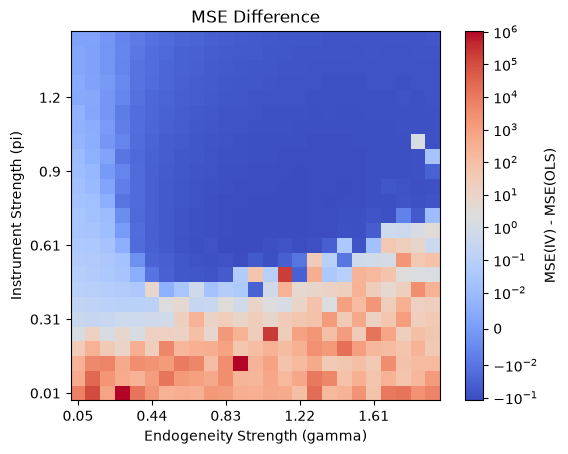

In [7]:
data_kwargs = dict(
    data_size = 100,
    beta = 1.0,
)

pi_vals = np.linspace(0.01, 1.5, 25)
gamma_vals = np.linspace(0.05, 2.0, 25)
results = np.zeros((len(pi_vals), len(gamma_vals)))
for p, pi in enumerate(pi_vals):
  data_kwargs["pi"] = pi
  for g, gamma in enumerate(gamma_vals):
    data_kwargs["gamma"] = gamma

    beta_IV_estimates = get_IV_estimates(N, **data_kwargs)
    beta_OLS_estimates = get_OLS_estimates(N, **data_kwargs)
    IV_mse = get_metrics(beta_IV_estimates, data_kwargs["beta"])["mse"]
    OLS_mse = get_metrics(beta_OLS_estimates, data_kwargs["beta"])["mse"]
    results[p, g] = IV_mse - OLS_mse

plot_heatmap(results)

### Conclusions


---
We proved mathematically that instrumental variables is consistent, thereby making it asymptotically unbiased, while ordinary least squares has a constant bias with respect to sample size. We also showed through Monte Carlo simulations that IV does perform better than OLS with large enough, finite sample sizes.

We also see that in practice, OLS is preferable to IV when any of sample size, instrument strength, or endogeneity strength is low because the variance in IV is more significant than the bias in OLS.